# プロジェクト：パーマー諸島のペンギンデータの可視化

## 分析目的

本データ分析レポートの目的は、パーマー諸島に生息するペンギンのサンプルに関する各変数を可視化し、種、性別、生息する島などの要因と、体重、くちばしの長さ・深さ、フリッパーの長さといった身体的特徴との関係を探索・分析することである。

## 概要

原始データ Penguins.csv には、南極のパーマー諸島にある3つの島で収集された334羽のペンギンのサンプルと、ペンギンに関する属性データが含まれている。属性には、種名、生息する島、くちばしの長さ、くちばしの深さ、フリッパーの長さ、体重、性別が含まれる。

Penguins.csv の各列の意味は以下のとおりである。

species：ペンギンの種

island：ペンギンが生息する島

culmen_length_mm：ペンギンのくちばしの長さ（単位：mm）

culmen_depth_mm：ペンギンのくちばしの深さ（単位：mm）

flipper_length_mm：ペンギンのフリッパーの長さ（単位：mm）

body_mass_g：ペンギンの体重（単位：g）

sex：ペンギンの性別

## データの読み込み

データ分析に必要なライブラリをインポートし、Pandas の read_csv 関数を使用して、元データファイル Penguins.csv の内容を DataFrame として読み込み、変数 original_data に代入します。

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

In [35]:
original_data = pd.read_csv("Penguins.csv")
original_data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## データの評価とクリーニング

前のセクションで作成した original_data DataFrame に含まれるデータを評価し、クリーニングする。

主に、構造と内容の2つの観点、すなわちデータの整然性とクリーンさの観点から確認する。

データの構造上の問題とは、次の3つの基準を満たしていない状態を指す。

各変数が1つの列になっている
各観測値が1つの行になっている
各観測単位の種類ごとに1つの表になっている

データの内容上の問題には、欠損データ、重複データ、無効なデータなどが含まれる。

In [36]:
cleaned_data = original_data.copy()

### データの整然性

In [37]:
cleaned_data.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


先頭10行のデータを見ると、データは「各変数が1つの列、各観測値が1つの行、各観測単位の種類ごとに1つの表」という基準を満たしているため、構造上の問題は存在しない。

### データのクリーンさ

info を使用して、データの内容を大まかに把握する。

In [38]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


出力結果から、cleaned_data には344件の観測値があり、culmen_length_mm、culmen_depth_mm、flipper_length_mm、body_mass_g の各変数には欠損値が存在することが分かる。これらについては、後続の処理で評価とクリーニングを行う。

データ型については、species（ペンギンの種）、sex（ペンギンの性別）、island（ペンギンが生息する島）はいずれもカテゴリデータであるため、データ型をすべて category に変換できる。

In [39]:
cleaned_data["species"] = cleaned_data["species"].astype("category")
cleaned_data["island"] = cleaned_data["island"].astype("category")
cleaned_data["sex"] = cleaned_data["sex"].astype("category")

In [40]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.0 KB


#### 欠損データの処理

info メソッドの出力から、cleaned_data では culmen_length_mm、culmen_depth_mm、flipper_length_mm、body_mass_g、sex の各変数に欠損値が存在することが分かる。

まず、これらの変数に欠損値がある観測値を抽出して確認する。

In [41]:
cleaned_data.query("culmen_length_mm.isna()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [42]:
cleaned_data.query("culmen_depth_mm.isna()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [43]:
cleaned_data.query("flipper_length_mm.isna()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [44]:
cleaned_data.query("body_mass_g.isna()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


以上から、インデックスが 3 と 339 の観測値は、種と生息する島を除くすべての変数が欠損していることが分かる。ペンギンの身体的特徴に関連する要因を探索するうえで有用な情報を提供できないため、この2行は直接削除できる。

In [45]:
cleaned_data.drop(3, inplace=True)
cleaned_data.drop(339, inplace=True)

In [46]:
cleaned_data.query("sex.isna()")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN


性別変数が欠損している観測値には、ほかのデータが含まれており、分析に有用な情報を提供できる。Pandas、Matplotlib、Seaborn は欠損値を自動的に無視するため、これらの行は残しておく。

#### 重複データの処理

データ変数の意味と内容から、変数の値が重複することは許容されるため、このデータについて重複値の有無を確認する必要はない。

#### 不整合なデータの処理

不整合なデータはすべてのカテゴリ変数に存在する可能性があるため、異なる値が実際には同じ対象を指していないか確認する必要がある。

In [47]:
cleaned_data["species"].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [48]:
cleaned_data["island"].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

In [49]:
cleaned_data["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

以上の出力から、species 列と island 列には不整合なデータは存在しないが、sex 列には英語のピリオド . が1つ含まれている。この値は有効な性別を表していないため、NaN の欠損値に置き換える必要がある。

In [50]:
cleaned_data['sex'] = cleaned_data['sex'].replace(".", np.nan)

In [51]:
cleaned_data["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           0
Name: count, dtype: int64

英語のピリオド . は欠損値に置き換えられたため、sex 列には不整合なデータは存在しない。

#### 無効または誤ったデータの処理

DataFrame の describe メソッドを使用すると、数値データの統計情報を素早く把握できる。

In [52]:
cleaned_data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


以上の統計情報から、cleaned_house_price には現実的な意味から逸脱した数値は存在しないことが分かる。

## データの探索

データを可視化して探索・分析を行い、グラフからペンギンのサンプルデータに関する洞察を得る。

In [53]:
# 设置图表色盘为"pastel"
sns.set_palette("pastel")

In [54]:
cleaned_data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


### ペンギンの種別割合

In [55]:
cleaned_data.groupby("species").size()

species
Adelie       151
Chinstrap     68
Gentoo       123
dtype: int64

In [56]:
species_count = cleaned_data["species"].value_counts()

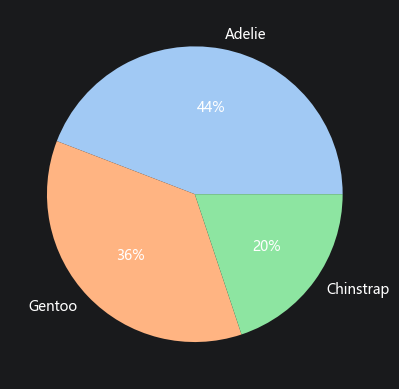

In [57]:
plt.pie(species_count, labels=species_count.index, autopct="%.0f%%")
plt.show()

サンプルでは、Adelie 種のペンギンが最も大きな割合を占め、次いで Gentoo 種が多く、Chinstrap 種が最も少なく、全体の約5分の1を占めている。

### ペンギンが生息する島の割合

In [58]:
island_count = cleaned_data["island"].value_counts()

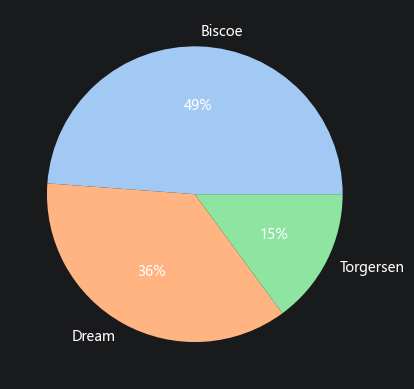

In [59]:
plt.pie(island_count, labels=island_count.index, autopct="%.0f%%")
plt.show()

サンプルでは、約半数のペンギンが Biscoe 島から収集されており、最も大きな割合を占めている。次いで Dream 島が多く、Torgersen 島から収集されたサンプルが最も少ない。

### ペンギンの性別割合

In [60]:
sex_count = cleaned_data["sex"].value_counts()

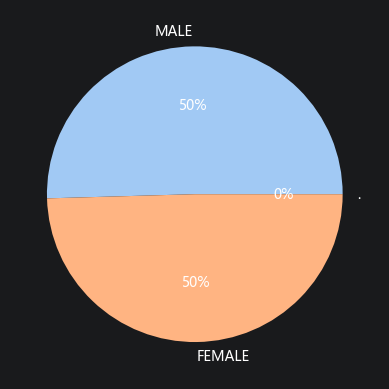

In [61]:
plt.pie(sex_count, labels=sex_count.index, autopct="%.0f%%")
plt.show()

サンプルにおけるペンギンの性別割合はほぼ同じであり、無作為抽出の結果として妥当である。

### 島ごとのペンギンの種別数

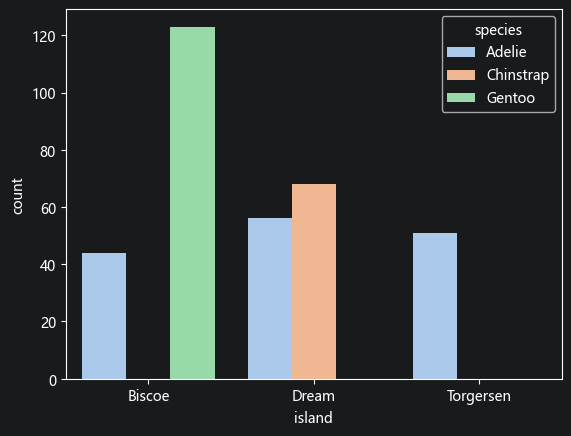

In [62]:
sns.countplot(cleaned_data, x="island", hue="species")
plt.show()

以上から、Adelie 種のペンギンのサンプルは Biscoe、Dream、Torgersen の3つの島すべてに存在する。一方、Chinstrap 種は Dream 島にのみ、Gentoo 種は Biscoe 島にのみ存在する。

### 島ごとのペンギンの性別数

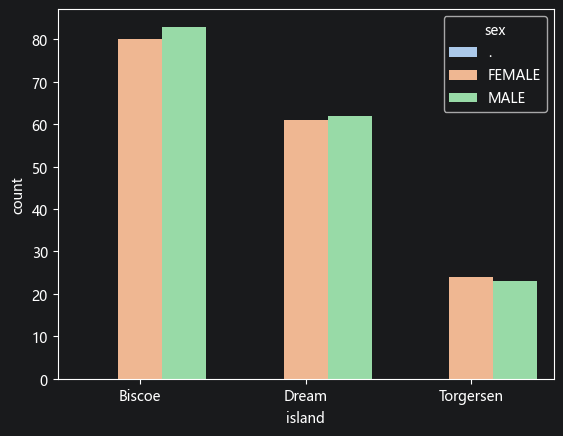

In [63]:
sns.countplot(cleaned_data, x="island", hue="sex")
plt.show()

### 数値間の相関関係の確認

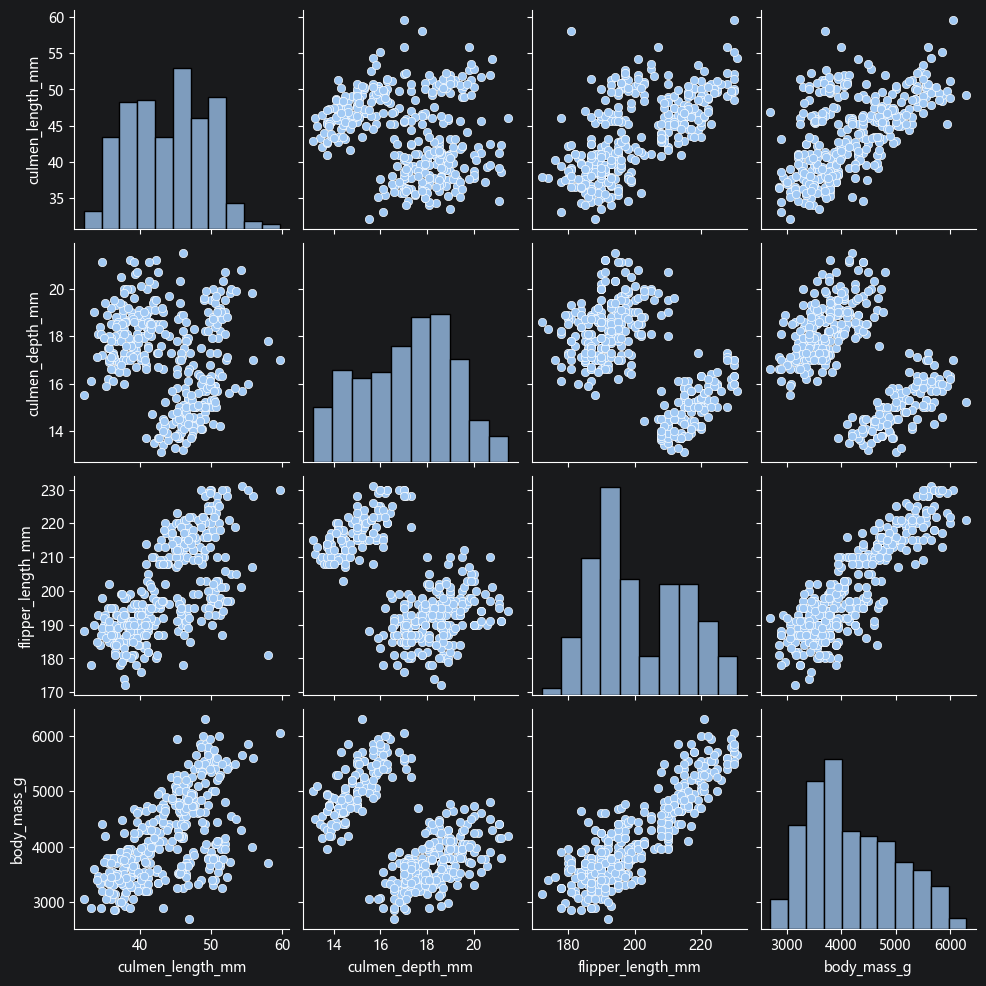

In [64]:
sns.pairplot(cleaned_data)
plt.show()

ヒストグラムを見ると、ペンギンのサンプルにおけるくちばしの長さ、くちばしの深さ、フリッパーの長さ、体重の分布は正規分布ではないことが分かる。これは、異なる特徴を持つ複数のサンプル群が含まれている可能性を示す一方で、サンプル数が十分に多くない可能性も示している。

また、散布図には複数の明確なクラスターが見られ、ペンギンの種や性別などの要因と関係している可能性がある。そのため、これらの分類変数に基づいて、さらに比較・分析を行う。

### 種別に数値間の相関関係を確認

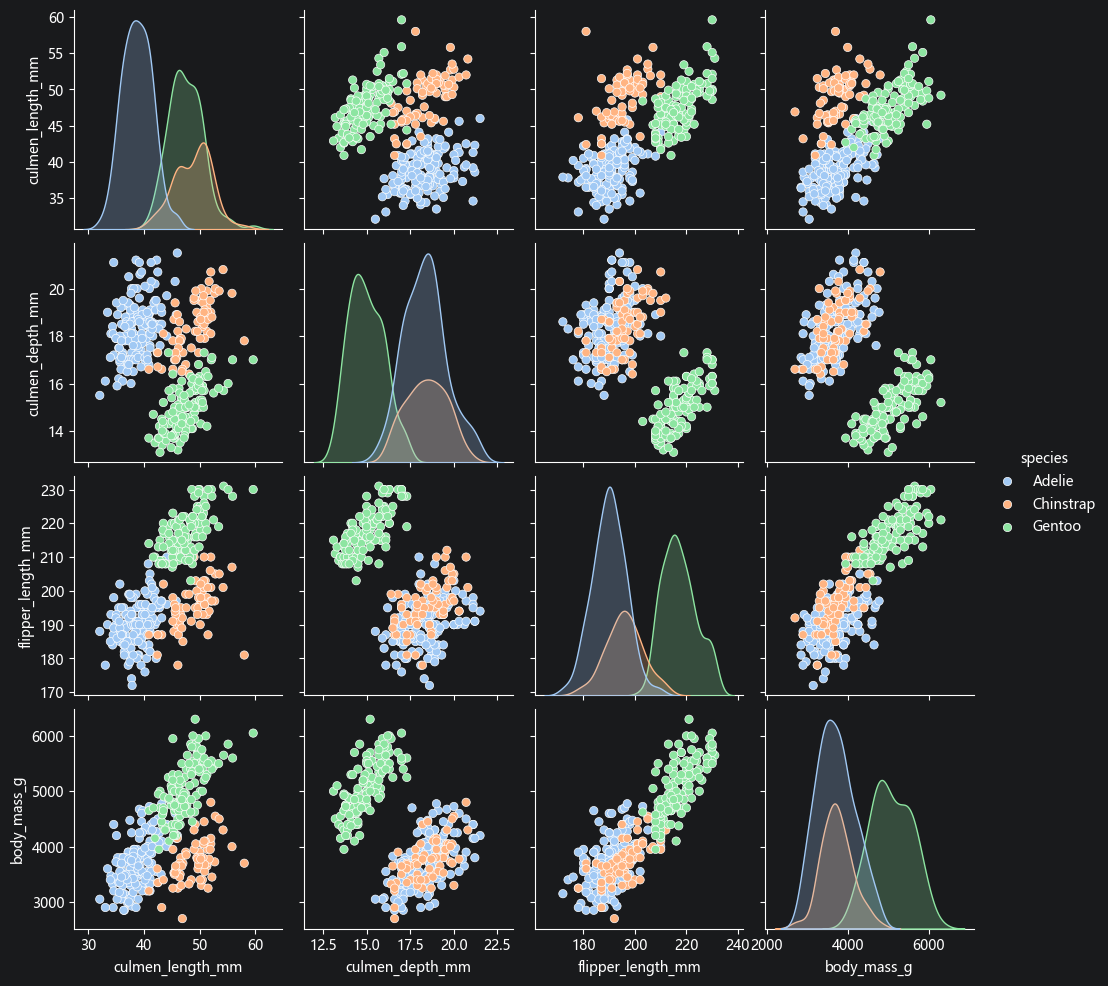

In [65]:
sns.pairplot(cleaned_data, hue="species")
plt.show()

同じ種のペンギンのサンプルデータは、散布図上でおおむね同じ領域に集まっている。これは、同じ種のペンギンが、くちばしの長さ、くちばしの深さ、フリッパーの長さ、体重の関係において類似した特徴を持つことを示している。

この結果から、体重やフリッパーの長さなどの数値を用いてペンギンの種を推定できる可能性があり、反対に、ペンギンの種から体重やフリッパーの長さなどの数値を推測できる可能性もある。

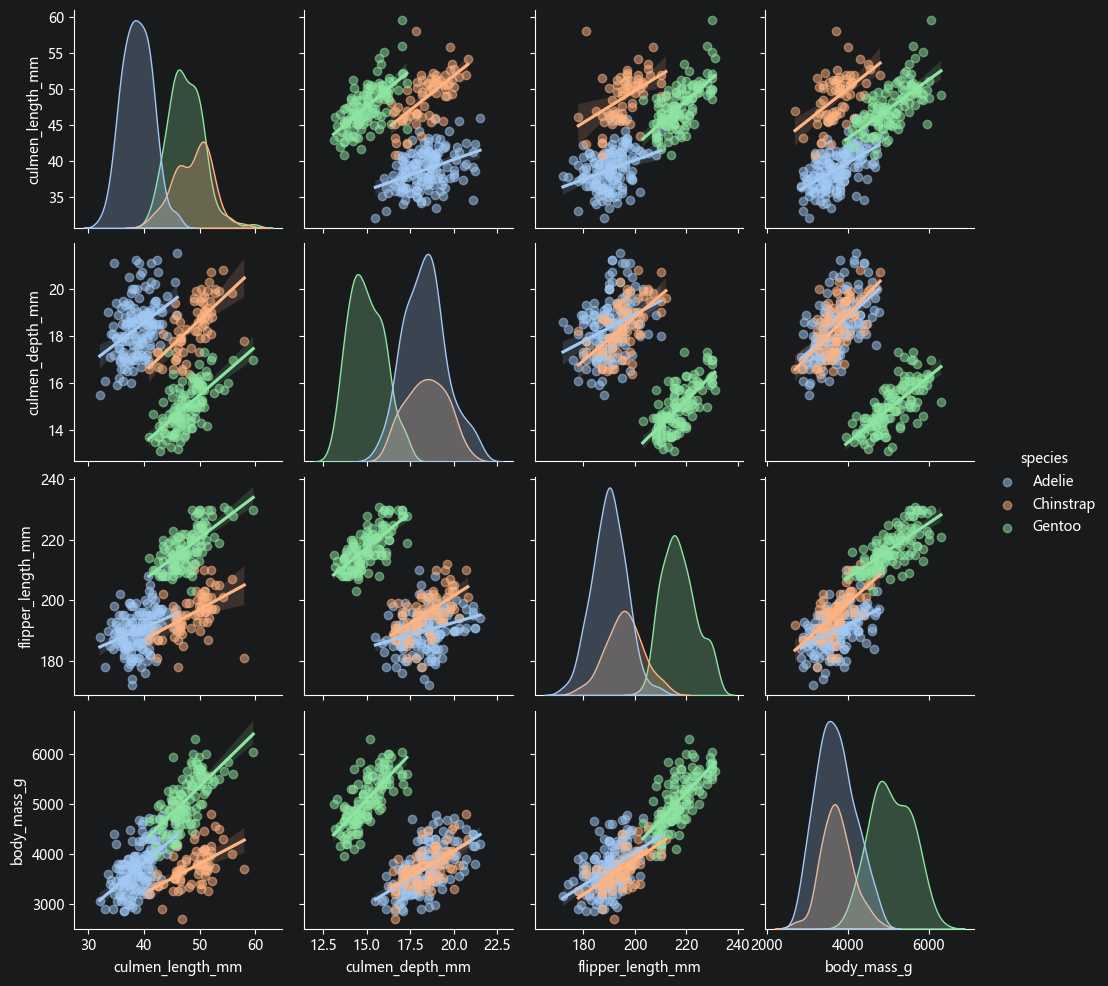

In [69]:
sns.pairplot(cleaned_data, hue="species", kind="reg", plot_kws={'scatter_kws': {'alpha': 0.5}}) # 按species分类着色，为每组数据添加回归线，并将散点透明度设置为0.5。由于 kind="reg" 的图形由两部分组成：散点、回归线，因此需要通过 scatter_kws 专门设置散点样式。
plt.show()

散布図と線形回帰直線を合わせて見ると、同じ種のペンギンでは各身体的特徴の間におおむね正の線形関係が見られる。すなわち、くちばしが長いほどくちばしは深く、フリッパーは長く、体重は重い傾向があり、反対に、くちばしが短いほどくちばしは浅く、フリッパーは短く、体重は軽い傾向がある。

密度分布図から、サンプルについて以下のことが分かる。

Chinstrap と Gentoo のくちばしの長さの範囲は比較的近く、Adelie のくちばしはより短い。

Adelie と Chinstrap のくちばしの深さの範囲は比較的近く、Gentoo のくちばしはより浅い。

フリッパーの長さは Adelie が最も短く、Chinstrap が中程度で、Gentoo が最も長い。

Adelie と Chinstrap の体重範囲は比較的近く、Gentoo の体重はより重い。

ただし、種による各属性値の差が統計的に有意であるかどうかについては、仮説検定を行ったうえで判断する必要がある。

### 性別ごとに数値間の相関関係を確認

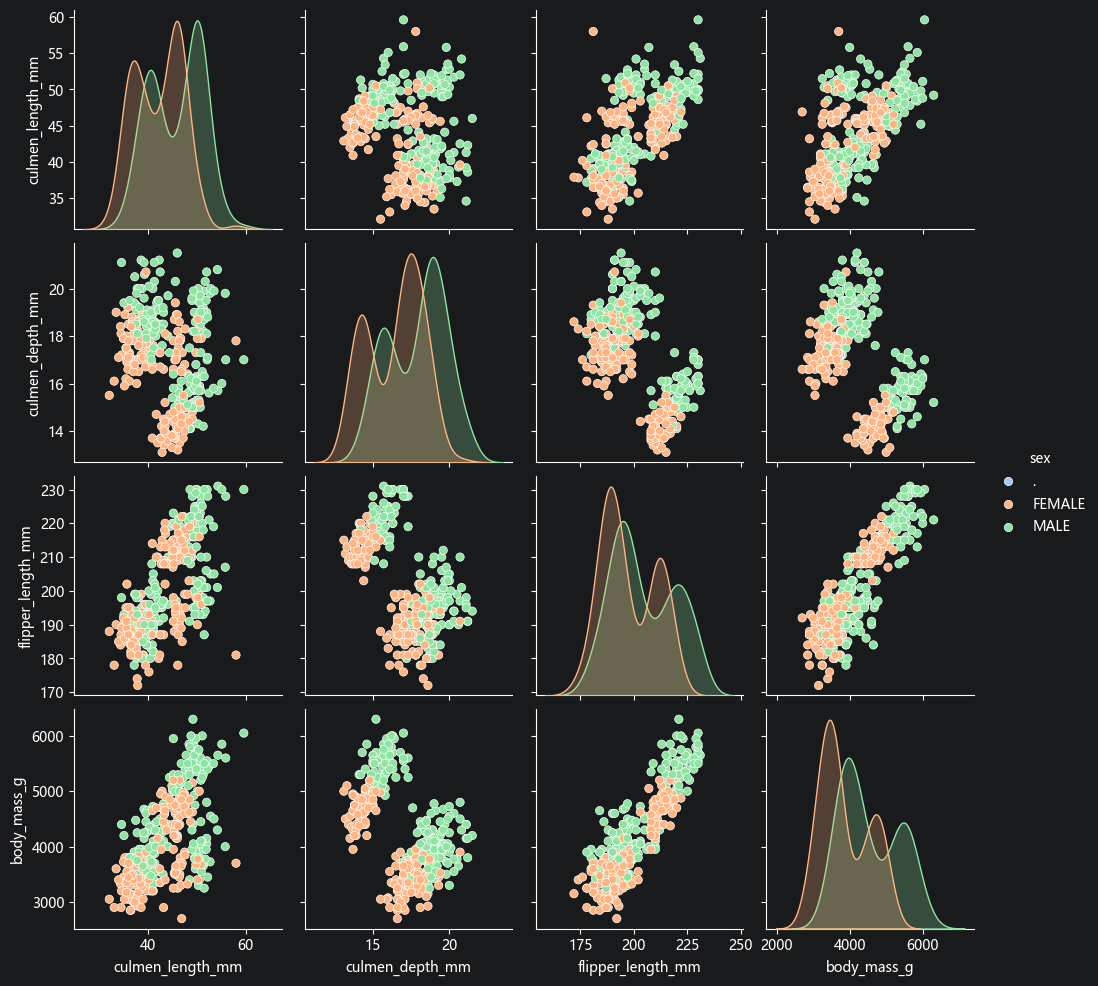

In [70]:
sns.pairplot(cleaned_data, hue="sex")
plt.show()

性別ごとに分けて見ると、サンプルではオスのペンギンの各属性値がメスのペンギンよりも大きいことが分かる。